# Methods Notebook: Extracting Call Samples for KMeans Clustering

## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import librosa
import warnings

In [3]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [5]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [6]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [7]:
def convert_nabatdf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] =  (df['peak_time_ms']-50)/1000
    raven_df['End Time (s)'] = (df['peak_time_ms']-40)/1000
    raven_df['Low Freq (Hz)'] = df['peak_freq_hz']-2000
    raven_df['High Freq (Hz)'] = df['peak_freq_hz']+2000
    raven_df['prediction'] = df['prediction']
    raven_df['score'] = df['score']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_nabatdf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = (df['peak_time_ms']-50)/1000
    bd2_df['end_time'] = (df['peak_time_ms']-40)/1000
    bd2_df['low_freq'] = df['peak_freq_hz']-2000
    bd2_df['high_freq'] = df['peak_freq_hz']+2000
    bd2_df['prediction'] = df['prediction']
    bd2_df['score'] = df['score']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_kaleidoscopedf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] = df['OFFSET']
    raven_df['End Time (s)'] = df['OFFSET'] + df['DURATION']
    raven_df['Low Freq (Hz)'] = df['Fmin']
    raven_df['High Freq (Hz)'] = df['Fmax']
    raven_df['input_file'] = df['IN FILE']
    raven_df['input_dir'] = df['INDIR']
    raven_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        raven_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        raven_df['TOP1MATCH'] = df['TOP1MATCH']
    raven_df['TOP1DIST'] = df['TOP1DIST']
    raven_df['TOP2MATCH'] = df['TOP2MATCH']
    raven_df['TOP2DIST'] = df['TOP2DIST']
    raven_df['TOP3MATCH'] = df['TOP3MATCH']
    raven_df['TOP3DIST'] = df['TOP3DIST']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_kaleidoscopedf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = df['OFFSET']
    bd2_df['end_time'] = df['OFFSET'] + df['DURATION']
    bd2_df['low_freq'] = df['Fmin']
    bd2_df['high_freq'] = df['Fmax']
    bd2_df['input_file'] = df['IN FILE']
    bd2_df['input_dir'] = df['INDIR']
    bd2_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        bd2_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        bd2_df['TOP1MATCH'] = df['TOP1MATCH']
    bd2_df['TOP1DIST'] = df['TOP1DIST']
    bd2_df['TOP2MATCH'] = df['TOP2MATCH']
    bd2_df['TOP2DIST'] = df['TOP2DIST']
    bd2_df['TOP3MATCH'] = df['TOP3MATCH']
    bd2_df['TOP3DIST'] = df['TOP3DIST']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_raventxtdf_to_bd2df(raventxt_df):
    bd2_human_df = raventxt_df[1::2].copy()
    bd2_human_df = bd2_human_df.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB',
                                'Delta Time (s)':'delta_time_s'}, inplace=True)
    bd2_human_df.sort_values('start_time', inplace=True)
    
    return bd2_human_df

def convert_bd2df_ravenpro(df: pd.DataFrame):
    """
    Converts a dataframe to the format used by RavenPro
    """

    ravenpro_df = df.copy()

    ravenpro_df.rename(columns={
        "start_time": "Begin Time (s)",
        "end_time": "End Time (s)",
        "low_freq": "Low Freq (Hz)",
        "high_freq": "High Freq (Hz)",
        "event": "Annotation",
        "freq_group":"Manually-Verified Phonic Group",
        'snr_nist_quick_dB':'SNR NIST Quick (dB)',
        'delta_time_s':'Delta Time (s)'
    }, inplace=True)

    ravenpro_df["Selection"] = np.arange(0, df.shape[0]).astype('int') + 1
    ravenpro_df["View"] = "Waveform 1"
    ravenpro_df["Channel"] = "1"

    return ravenpro_df

In [8]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}
#  '20210910_030000':'Foliage'}
extension = ".txt"
sep = "\t"
raventxt_human_files_dir = f'{Path.home()}/Documents/mila-human-wav-txt'
bd2_dets_save_dir = Path(f'20250114__group_threshold_sweep_results')

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [9]:
wav_filename = '20220826_070000'
site = file_sites[wav_filename]
plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

In [10]:
snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_and_aditya_SNR.txt', sep=sep)
bd2_human_df = snr_included_ravenpro_human_txt.copy()
bd2_human_df = bd2_human_df.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df.sort_values('start_time', inplace=True)
bd2_human_df

,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB
0,1.729564,1.737108,44070.175,51087.719,0.0075,16.02,AK_echolocation,NaN,NaN,HF,2.567162
1,3.770500,3.777100,45234.000,54096.000,0.0066,14.64,Echolocation,0.512,20220826_070000.WAV,HF,6.879404
2,3.911402,3.918947,43903.720,56927.790,0.0075,12.74,AK_echolocation,NaN,NaN,HF,7.902035
3,4.043419,4.050209,44281.690,58478.873,0.0068,12.10,AK_echolocation,NaN,NaN,HF,1.782390
4,4.161126,4.170934,43903.720,56507.659,0.0098,12.35,AK_echolocation,NaN,NaN,HF,1.514990
...,...,...,...,...,...,...,...,...,...,...,...
4401,1787.774500,1787.784900,37500.000,46675.000,0.0104,16.86,Echolocation,0.587,20220826_070000.WAV,HF,9.656562
4402,1787.959500,1787.969400,37500.000,45913.000,0.0099,14.98,Echolocation,0.591,20220826_070000.WAV,HF,6.562988
4403,1788.212500,1788.221200,39218.000,48186.000,0.0087,13.74,Echolocation,0.544,20220826_070000.WAV,HF,8.990165
4404,1788.413500,1788.422500,40078.000,49982.000,0.0090,14.89,Echolocation,0.566,20220826_070000.WAV,HF,5.589297


In [13]:
def plot_audio_seg(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()


def plot_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(10, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    Pxx, freqs, t, im = plt.specgram(audio_seg, NFFT=nfft, Fs=fs, cmap=cmap, vmin=vmin, vmax=vmax)

    ax = plt.gca()
    if len(plot_dets)>0:
        plot_dets = plot_dets[(plot_dets['start_time']>=start)&(plot_dets['end_time']<=(start+duration))]
        for i, row in plot_dets.iterrows():
            rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                            (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                            linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
            ax.add_patch(rect)
            ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

    plt.yticks(ticks=np.linspace(0, 256e3/2, 6).astype('int'), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration, 6), 
               labels=np.linspace(start, start+duration, 6, dtype=plot_xtype), rotation=0)
    plt.xlabel("Time (s)")
    plt.twinx(ax=ax)
    plt.yticks(ticks=np.linspace(0, 256e3/2, 6).astype('int'), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plt.ylim(0, 256e3/2)

    plt.show()
    return Pxx

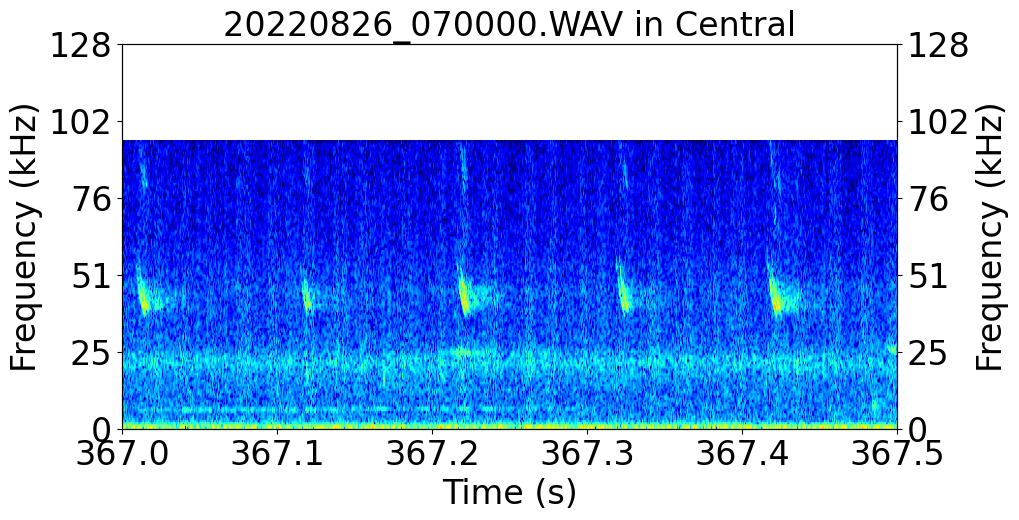

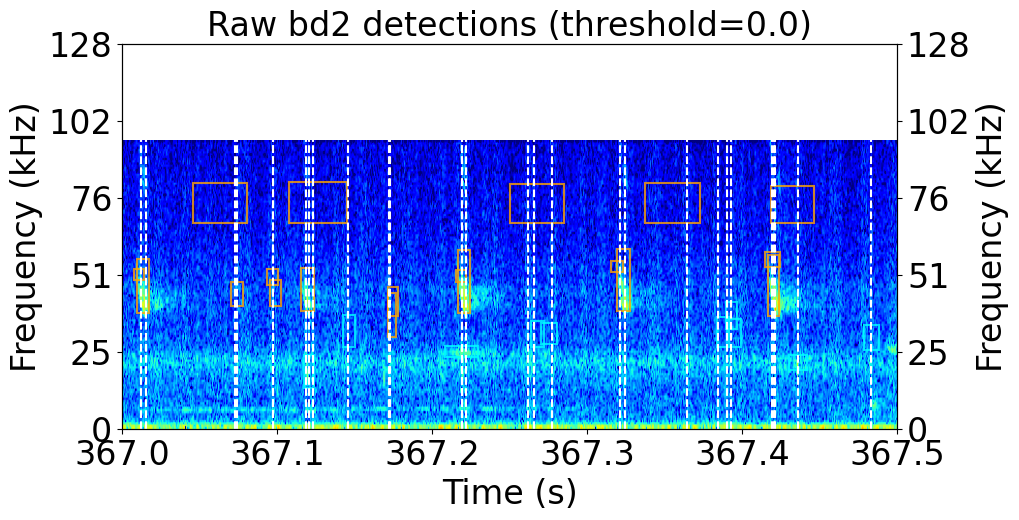

In [14]:
# Below we filter our detections dataframe to only get the detections corresponding to the above audio file
audio_file = sf.SoundFile(plot_file)
fs = audio_file.samplerate
start = 367
duration = 0.5
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmin = -120
vmax = -40
audio_features = dict()
audio_features['file_path'] = Path(plot_file)
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration

spec_features = dict()
spec_features['NFFT'] = 256 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax


spec_features['plot_title'] = f"{audio_features['file_path'].name} in {site}"
Pxx = plot_dets_over_audio(audio_features, spec_features, pd.DataFrame())

plot_thresh = 0.00
args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00

ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")

filepath = bd2_dets_save_dir / save_loc
batdetect2_df = pd.read_csv(filepath, sep=',', index_col=0)
batdetect2_df.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
batdetect2_df_selected = batdetect2_df[batdetect2_df['det_prob']>=plot_thresh].copy()
spec_features['plot_title'] = f"Raw bd2 detections (threshold={plot_thresh})"
Pxx = plot_dets_over_audio(audio_features, spec_features, batdetect2_df_selected)

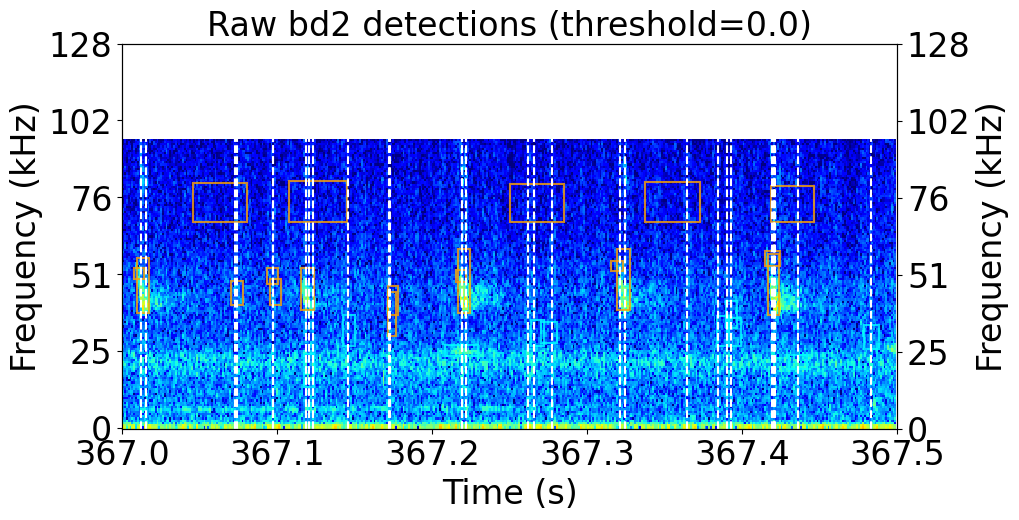

In [15]:
audio_seg = audio_features['audio_seg']
fs = audio_features['sample_rate']
start = audio_features['start']
duration = audio_features['duration']
plot_dets = batdetect2_df_selected

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

plt.figure(figsize=(10, 5))
plt.rcParams.update({'font.size': 24})
plt.title(spec_features['plot_title'], fontsize=24)
mpl_specgram_window = plt.mlab.window_hanning(np.ones(nfft))
f, t, Sxx = scipy.signal.spectrogram(audio_seg, fs, detrend=False,
                               nfft=nfft, 
                               window=mpl_specgram_window
                              )
max_value_across_bins = Sxx[np.where(Sxx==np.max(Sxx))]
peak_freq = f[np.where(Sxx==np.max(Sxx))[0]]
peak_freq_time = t[np.where(Sxx==np.max(Sxx))[1]]
plt.pcolormesh(t, f, 10*np.log10(Sxx), cmap=cmap, vmin=vmin, vmax=vmax)
plt.axvline(x=peak_freq_time, linestyle='dashed', color='white')

ax = plt.gca()
if len(plot_dets)>0:
    plot_dets = plot_dets[(plot_dets['start_time']>=start)&(plot_dets['end_time']<=(start+duration))]
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor=FREQ_COLORS[row['freq_group']], facecolor='none', alpha=0.8)
        ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')
        ax.add_patch(rect)

plt.yticks(ticks=np.linspace(0, 256e3/2, 6), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plot_xtype = 'float'
if (duration > 60):
    plot_xtype = 'int'
plt.xticks(ticks=np.linspace(0, duration, 6), 
            labels=np.linspace(start, start+duration, 6, dtype=plot_xtype), rotation=0)
plt.xlabel("Time (s)")
plt.twinx(ax=ax)
plt.yticks(ticks=np.linspace(0, 256e3/2, 6), labels=np.linspace(0, 256e3/2000, 6).astype('int'))
plt.ylabel("Frequency (kHz)")
plt.ylim(0, 256e3/2)

plt.show()

In [16]:
example_bd2df = batdetect2_df_selected[(batdetect2_df_selected['start_time']>=start)&(batdetect2_df_selected['end_time']<=(start+duration))]
example_bd2df = example_bd2df.sort_values('peak_frequency_time_SPECTROGRAM')
example_bd2df

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
19785,HF,367.012200,48750.0,48960.0,11.394245,367.0075,367.0138,49531,53065,Pipistrellus pipistrellus,0.014,0.027,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
19786,HF,367.015233,41250.0,41280.0,20.285174,367.0095,367.0171,38359,56472,Pipistrellus nathusii,0.528,0.600,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
19788,HF,367.072833,47250.0,47040.0,1.434014,367.0705,367.0780,40937,48884,Pipistrellus nathusii,0.014,0.025,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
19787,HF,367.074100,69000.0,69120.0,2.134072,367.0455,367.0804,68437,81659,Rhinolophus ferrumequinum,0.023,0.024,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
19790,HF,367.097067,43500.0,44160.0,2.515247,367.0955,367.1026,40937,49476,Pipistrellus nathusii,0.064,0.075,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
19789,HF,367.097600,47250.0,47040.0,1.627009,367.0935,367.1004,47812,53073,Pipistrellus pipistrellus,0.019,0.029,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
19791,HF,367.118433,81750.0,81600.0,0.249616,367.1075,367.1449,68437,82106,Rhinolophus ferrumequinum,0.027,0.027,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
19792,HF,367.120333,41250.0,41280.0,14.138644,367.1155,367.1240,39218,53330,Pipistrellus nathusii,0.383,0.419,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
19793,LF,367.123167,21000.0,18240.0,1.973084,367.1175,367.1240,13437,24532,Barbastellus barbastellus,0.044,0.046,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
19794,LF,367.145600,31500.0,32640.0,0.909208,367.1425,367.1504,27187,37675,Eptesicus serotinus,0.007,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [17]:
next_calls_pftSPEC = example_bd2df['peak_frequency_time_SPECTROGRAM'][1:].reset_index(drop=True)
cur_calls_pftSPEC = example_bd2df['peak_frequency_time_SPECTROGRAM'][:-1].reset_index(drop=True)
pftSPEC_intervals = next_calls_pftSPEC - cur_calls_pftSPEC

In [18]:
pftSPEC_intervals

0     0.003033
1     0.057600
2     0.001267
3     0.022967
4     0.000533
5     0.020833
6     0.001900
7     0.002833
8     0.022433
9     0.026833
10    0.000067
11    0.046600
12    0.000033
13    0.002900
14    0.039767
15    0.003800
16    0.011633
17    0.044100
18    0.003200
19    0.039900
20    0.019833
21    0.005733
22    0.003000
23    0.026200
24    0.001300
25    0.000933
26    0.014300
27    0.047467
Name: peak_frequency_time_SPECTROGRAM, dtype: float64

In [19]:
next_calls_pftSPEC = batdetect2_df_selected.sort_values('peak_frequency_time_SPECTROGRAM')['peak_frequency_time_SPECTROGRAM'][1:].reset_index(drop=True)
cur_calls_pftSPEC = batdetect2_df_selected.sort_values('peak_frequency_time_SPECTROGRAM')['peak_frequency_time_SPECTROGRAM'][:-1].reset_index(drop=True)
pftSPEC_intervals = next_calls_pftSPEC - cur_calls_pftSPEC

In [20]:
pftSPEC_intervals

0        0.000000
1        0.007000
2        0.065067
3        0.007733
4        0.021367
           ...   
91447    0.005733
91448    0.008800
91449    0.021800
91450    0.011567
91451    0.025433
Name: peak_frequency_time_SPECTROGRAM, Length: 91452, dtype: float64

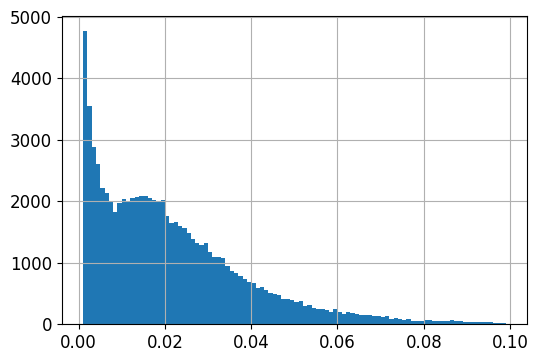

In [21]:
plt.figure(figsize=(6,4))
plt.rcParams.update({'font.size':12})
pftSPEC_intervals.hist(bins=np.arange(0.001,0.1,0.001))
plt.show()

In [20]:
FREQUENCY_COLOR_MAPPINGS = {'LF':'cyan', 'HF':'orange'}

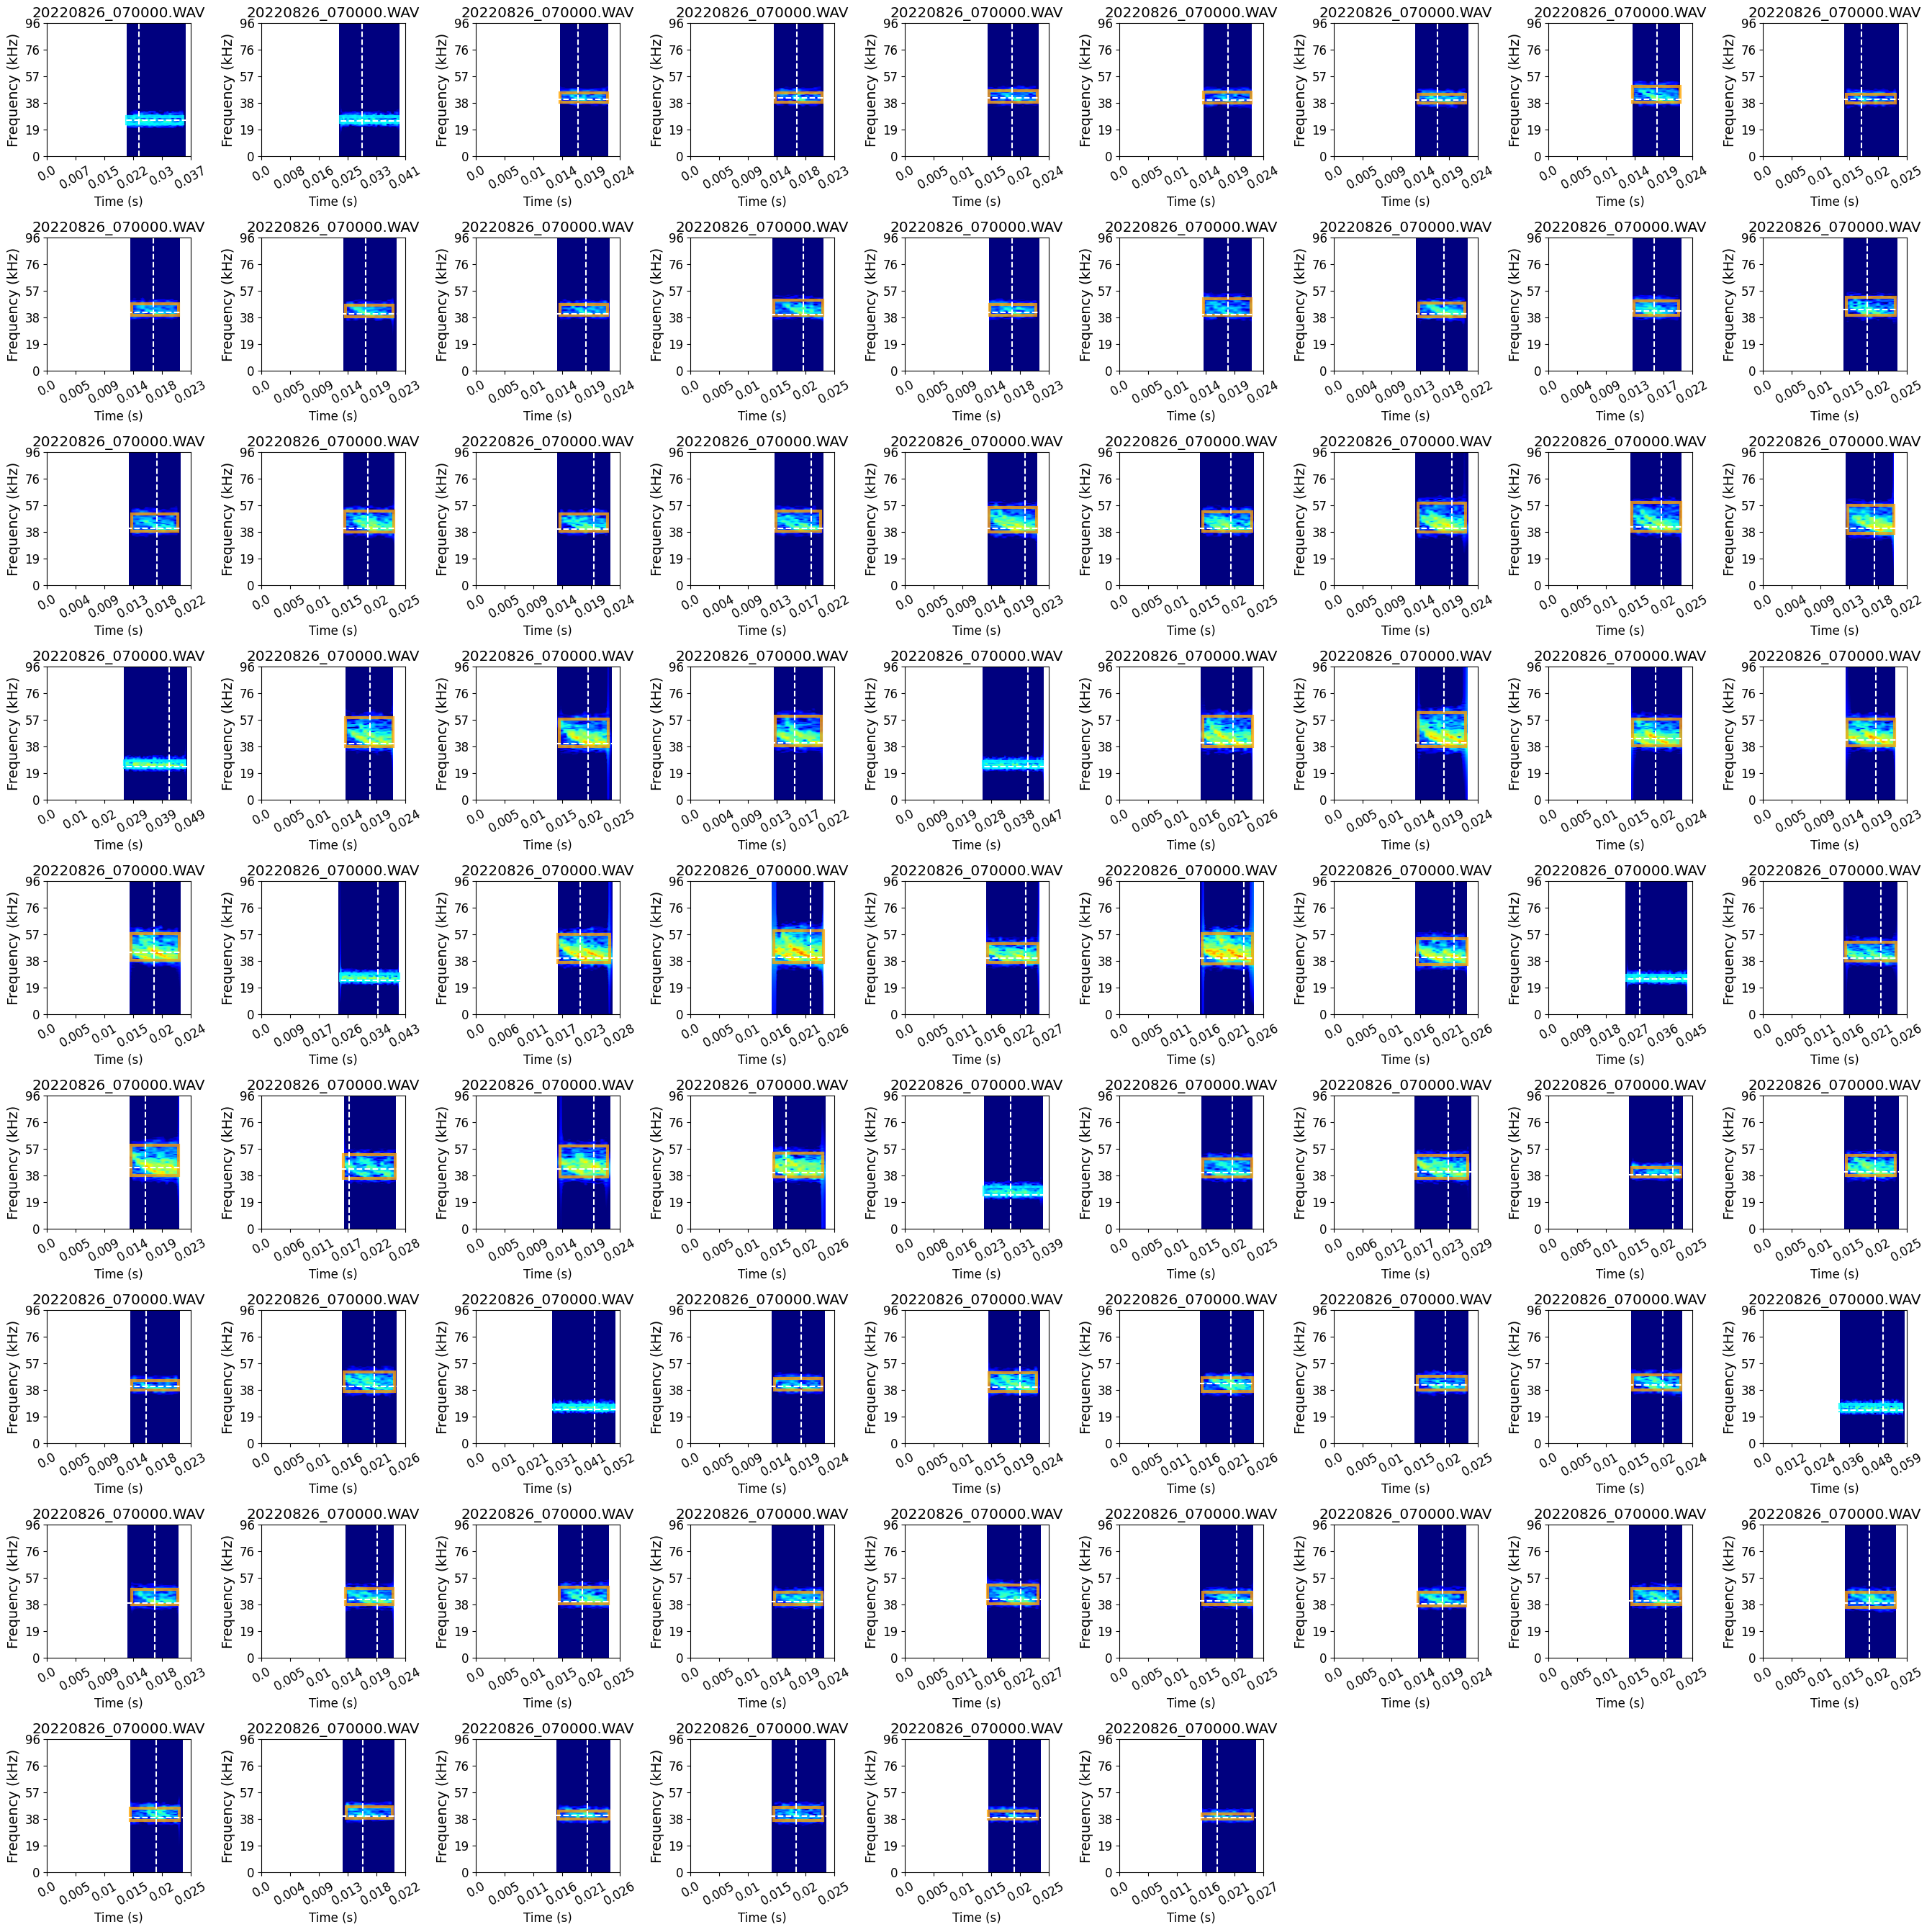

In [ ]:
cur_path = ''
subset = plot_dets.reset_index(drop=True)
matrix_side_length = int(np.ceil(len(subset)**0.5))
plt.figure(figsize=(3*matrix_side_length,3*matrix_side_length))
plt.rcParams.update({'font.size':12})

for j, row in subset.iterrows():
    plt.subplot(matrix_side_length, matrix_side_length, j+1)
    fs = audio_file.samplerate

    call_dur = (row['end_time'] - row['start_time'])
    pad = min(min(row['start_time'] - call_dur, 1795 - row['end_time']), 0.006) / 3
    start = row['start_time'] - call_dur - (3*pad)
    duration = (2 * call_dur) + (4*pad)
    audio_file.seek(int(fs*start))
    audio_seg = audio_file.read(int(fs*duration))
    length_of_section = call_dur + (2*pad)
    
    freq_pad = 2000
    low_freq_cutoff = row['low_freq']-freq_pad
    high_freq_cutoff = min((fs//2)-1, row['high_freq']+freq_pad)
    band_limited_audio_seg = batdetect2_pipeline.bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

    signal_for_peaks = band_limited_audio_seg.copy()
    signal_for_peaks[:int(fs*(length_of_section+pad))] = 0
    signal_for_peaks[-int(fs*pad):] = 0
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(256))
    f, t, Sxx = scipy.signal.spectrogram(signal_for_peaks, fs, detrend=False,
                                nfft=256, 
                                window=mpl_specgram_window
                                )
    plt_Sxx = 10*np.log10(Sxx)
    max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
    max_value_across_bins = Sxx[max_ind]
    peak_freq = f[max_ind[0]]
    peak_freq_time = t[max_ind[1]]

    plt.title(f'{plot_file.name}')
    plt.specgram(signal_for_peaks, Fs=fs, NFFT=256, cmap='jet', vmin=-120, vmax=-40)

    ax = plt.gca()
    rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=3, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    plt.axhline(y=peak_freq, linestyle='dashed', color='w')
    plt.axvline(x=peak_freq_time, linestyle='dashed', color='w')

    plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)", fontsize=14)
    plt.text(x=0.001,y=85000, s=f'{row["freq_group"]} det{j}', fontweight='bold', color='w')
    plt.xticks(ticks=np.linspace(0, len(audio_seg)/fs, 6), labels=np.round(np.linspace(0, len(audio_seg)/fs, 6, dtype=float), 3), rotation=30)
    plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [135]:
Pxx

array([[7.10761615e-08, 1.34625477e-07, 1.16514537e-07, ...,
        6.28465213e-08, 2.70101988e-07, 6.05111582e-07],
       [8.24098652e-08, 1.90784539e-07, 1.00582158e-07, ...,
        1.92128497e-07, 1.45497760e-07, 4.23262374e-07],
       [4.31066948e-08, 5.83809002e-08, 2.10199637e-08, ...,
        2.82790742e-08, 2.09450829e-08, 1.56773543e-08],
       ...,
       [6.69931333e-11, 6.32583344e-13, 5.72116550e-12, ...,
        1.28057164e-11, 1.90248897e-11, 7.45528736e-12],
       [2.09706565e-11, 1.12956569e-11, 4.92874693e-13, ...,
        1.71102254e-12, 1.07432133e-11, 5.23265471e-12],
       [5.54191369e-13, 3.90523609e-12, 1.10736788e-12, ...,
        4.93552011e-12, 1.52869606e-11, 1.33652932e-11]])

In [136]:
Sxx

array([[7.10761615e-08, 1.34625477e-07, 1.16514537e-07, ...,
        6.28465213e-08, 2.70101988e-07, 6.05111582e-07],
       [8.24098652e-08, 1.90784539e-07, 1.00582158e-07, ...,
        1.92128497e-07, 1.45497760e-07, 4.23262374e-07],
       [4.31066948e-08, 5.83809002e-08, 2.10199637e-08, ...,
        2.82790742e-08, 2.09450829e-08, 1.56773543e-08],
       ...,
       [6.69931333e-11, 6.32583344e-13, 5.72116550e-12, ...,
        1.28057164e-11, 1.90248897e-11, 7.45528736e-12],
       [2.09706565e-11, 1.12956569e-11, 4.92874693e-13, ...,
        1.71102254e-12, 1.07432133e-11, 5.23265471e-12],
       [5.54191369e-13, 3.90523609e-12, 1.10736788e-12, ...,
        4.93552011e-12, 1.52869606e-11, 1.33652932e-11]])

In [137]:
Sxx_to_Pxx_dB = 10*np.log10(Sxx/Pxx)
print(f'Largest difference (ratio in dB) : {np.abs(Sxx_to_Pxx_dB).max():4.3G}')

Largest difference (ratio in dB) : 2.67E-11


In [19]:
ravenpro_df = convert_bd2df_ravenpro(batdetect2_df)
ravenpro_df.to_csv(f'{bd2_dets_save_dir}/20250113__{save_loc.stem}.txt', sep=sep, index=False)

In [14]:
def remove_overlaps_between_two_dfs(batdetect2_df, debug=False):
    current_ind = 0
    next_ind = 1

    pairs_df = pd.DataFrame()
    num_original_dets = len(batdetect2_df)
    while (next_ind < len(batdetect2_df)):
        current_det = batdetect2_df.iloc[current_ind]
        next_det = batdetect2_df.iloc[next_ind]

        next_det_start_in_cur_det_bounds = ((next_det['start_time']>=current_det['start_time'])&(next_det['start_time']<=current_det['end_time']))
        next_det_end_in_cur_det_bounds = ((next_det['end_time']>=current_det['start_time'])&(next_det['end_time']<=current_det['end_time']))
        cur_det_start_in_next_det_bounds = ((current_det['start_time']>=next_det['start_time'])&(current_det['start_time']<=next_det['end_time']))
        cur_det_end_in_next_det_bounds = ((current_det['end_time']>=next_det['start_time'])&(current_det['end_time']<=next_det['end_time']))
        next_det_time_in_cur_bounds = next_det_start_in_cur_det_bounds|next_det_end_in_cur_det_bounds
        cur_det_time_in_next_bounds = cur_det_start_in_next_det_bounds|cur_det_end_in_next_det_bounds

        next_det_low_in_cur_det_bounds = ((next_det['low_freq']>=current_det['low_freq'])&(next_det['low_freq']<=current_det['high_freq']))
        next_det_high_in_cur_det_bounds = ((next_det['high_freq']>=current_det['low_freq'])&(next_det['high_freq']<=current_det['high_freq']))
        cur_det_low_in_next_det_bounds = ((current_det['low_freq']>=next_det['low_freq'])&(current_det['low_freq']<=next_det['high_freq']))
        cur_det_high_in_next_det_bounds = ((current_det['high_freq']>=next_det['low_freq'])&(current_det['high_freq']<=next_det['high_freq']))
        next_det_freq_in_cur_bounds = next_det_low_in_cur_det_bounds|next_det_high_in_cur_det_bounds
        cur_det_freq_in_next_bounds = cur_det_low_in_next_det_bounds|cur_det_high_in_next_det_bounds

        next_det_time_matches_cur_time = (next_det_time_in_cur_bounds|cur_det_time_in_next_bounds)
        next_det_freq_matches_cur_time = (next_det_freq_in_cur_bounds|cur_det_freq_in_next_bounds)
        next_detection_corresponds_to_current = next_det_time_matches_cur_time&next_det_freq_matches_cur_time

        if debug:
            print(f'BEFORE CHECK CUR:{current_ind} at {current_det["start_time"]}, NEXT:{next_ind} at {next_det["start_time"]}')
            print(f'Dets match time: {next_det_time_matches_cur_time}, Dets match freq: {next_det_freq_matches_cur_time}')
        
        if (next_detection_corresponds_to_current):
            if len(pairs_df)==0:
                pairs_df = pd.DataFrame(columns=next_det.keys())
            batdetect2_df = batdetect2_df.drop(next_ind).reset_index(drop=True)
            pairs_df.loc[len(pairs_df)] = current_det
            pairs_df.loc[len(pairs_df)] = next_det
            print(f'Overlap found around {next_det["start_time"]}s')
        else:
            current_ind += 1
            next_ind += 1

        # print(f'AFTER CHECK CUR:{current_ind}, NEXT:{next_ind}')
    
    assert(len(batdetect2_df) + (len(pairs_df)/2))==num_original_dets
    return batdetect2_df, pairs_df

In [16]:
len(batdetect2_df)

91453

In [235]:
batdetect2_df_for_overlap_removal = batdetect2_df_selected.sort_values('start_time').reset_index(drop=True)
batdetect2_df_for_overlap_removal

,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,HF,45120.0,0.954735,1.4185,1.4305,44375,47893,Pipistrellus pipistrellus,0.189,0.234,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
1,LF,36480.0,1.868827,7.3655,7.3722,33203,40594,Barbastellus barbastellus,0.147,0.294,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
2,LF,35520.0,1.402877,11.2955,11.3078,34062,38393,Eptesicus serotinus,0.092,0.268,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
3,LF,35520.0,1.800644,15.9505,15.9568,33203,41318,Barbastellus barbastellus,0.110,0.233,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
4,LF,35520.0,2.651042,16.7375,16.7442,33203,40866,Barbastellus barbastellus,0.123,0.281,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6296,LF,23040.0,1.170074,1783.1985,1783.2102,22031,29535,Nyctalus noctula,0.164,0.314,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
6297,LF,35520.0,2.359290,1787.0605,1787.0700,34062,39401,Barbastellus barbastellus,0.081,0.204,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
6298,LF,35520.0,1.898337,1791.7145,1791.7217,32343,38830,Eptesicus serotinus,0.091,0.209,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
6299,LF,35520.0,3.042239,1794.1385,1794.1462,33203,38398,Barbastellus barbastellus,0.158,0.294,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...


In [236]:
batdetect2_df_removed_overlaps, batdetect2_df_overlaps = remove_overlaps_between_two_dfs(batdetect2_df_for_overlap_removal, debug=False)

Overlap found around 582.0575s
Overlap found around 582.3005s
Overlap found around 582.5385s
Overlap found around 647.8795s
Overlap found around 648.9615s
Overlap found around 649.3685s
Overlap found around 649.7835s
Overlap found around 649.8405s
Overlap found around 650.8645s
Overlap found around 692.7805s
Overlap found around 700.0605s
Overlap found around 704.0205s
Overlap found around 708.6385s
Overlap found around 734.8805s
Overlap found around 744.7675s
Overlap found around 746.8435s
Overlap found around 747.0995s
Overlap found around 747.1455s
Overlap found around 748.8415s
Overlap found around 749.1065s
Overlap found around 749.2245s
Overlap found around 764.2995s
Overlap found around 764.4465s
Overlap found around 764.5025s
Overlap found around 764.5505s
Overlap found around 765.0385s
Overlap found around 765.3815s
Overlap found around 765.4535s
Overlap found around 765.7915s
Overlap found around 772.4475s
Overlap found around 832.4935s
Overlap found around 876.3935s
Overlap 

In [237]:
batdetect2_df_overlaps

,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,LF,23040.0,27.46586,582.0425,582.0633,22031,31219,Nyctalus noctula,0.407,0.579,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
1,LF,22080.0,12.610467,582.0575,582.0751,20312,26254,Nyctalus noctula,0.242,0.321,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
2,LF,22080.0,32.599252,582.2885,582.3108,21171,28890,Nyctalus noctula,0.412,0.614,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
3,LF,22080.0,13.093604,582.3005,582.3169,20312,27651,Nyctalus noctula,0.202,0.252,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
4,LF,23040.0,28.016923,582.5265,582.546,21171,27457,Nyctalus noctula,0.382,0.514,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,LF,26880.0,12.085228,1654.1555,1654.1683,25468,32515,Nyctalus leisleri,0.259,0.398,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
224,LF,25920.0,4.504397,1659.2815,1659.3,23750,27027,Nyctalus leisleri,0.229,0.34,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
225,LF,25920.0,5.588237,1659.2945,1659.3003,23750,36346,Plecotus austriacus,0.125,0.28,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...
226,LF,26880.0,13.200499,1676.5945,1676.6137,25468,31826,Eptesicus serotinus,0.163,0.384,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...


In [90]:
ravenpro_df = convert_bd2df_ravenpro(batdetect2_df_removed_overlaps)
ravenpro_df

,Manually-Verified Phonic Group,peak_frequency,SNR,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),class,class_prob,det_prob,individual,Annotation,sampling_rate,input_file,Selection,View,Channel
0,HF,45120.0,0.954735,1.4185,1.4305,44375,47893,Pipistrellus pipistrellus,0.189,0.234,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...,1,Waveform 1,1
1,LF,36480.0,1.868827,7.3655,7.3722,33203,40594,Barbastellus barbastellus,0.147,0.294,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...,2,Waveform 1,1
2,LF,35520.0,1.402877,11.2955,11.3078,34062,38393,Eptesicus serotinus,0.092,0.268,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...,3,Waveform 1,1
3,LF,35520.0,1.800644,15.9505,15.9568,33203,41318,Barbastellus barbastellus,0.11,0.233,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...,4,Waveform 1,1
4,LF,35520.0,2.651042,16.7375,16.7442,33203,40866,Barbastellus barbastellus,0.123,0.281,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...,5,Waveform 1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6293,LF,26880.0,2.90108,1782.4335,1782.4447,26328,31454,Eptesicus serotinus,0.162,0.345,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...,6294,Waveform 1,1
6294,LF,27840.0,4.490641,1782.5735,1782.5819,26328,34609,Eptesicus serotinus,0.31,0.511,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...,6295,Waveform 1,1
6295,LF,27840.0,2.85913,1782.6955,1782.7051,26328,33775,Eptesicus serotinus,0.252,0.408,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...,6296,Waveform 1,1
6296,LF,23040.0,1.170074,1783.1985,1783.2102,22031,29535,Nyctalus noctula,0.164,0.314,-1,Echolocation,250000,/home/adkris/Documents/mila-human-wav-txt/2021...,6297,Waveform 1,1


In [92]:
ones = int(plot_thresh)
decimals = int(int(100*(plot_thresh)) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REMOVED_OVERLAPS.csv")

In [93]:
ravenpro_df.to_csv(f'20250110__{Path(save_loc).stem}.txt', sep=sep, index=False)